<a href="https://colab.research.google.com/github/Lingeshkumar24-code/NLP-projects/blob/main/NLP_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import nltk
import re
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from textblob import TextBlob
from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('stopwords')
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')   # Add this line
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [15]:
comments = [
    "This product is amazing!",
    "Worst customer service ever.",
    "I love the new design.",
    "Very disappointed with the quality.",
    "Excellent experience.",
    "Not worth the money.",
    "Fast delivery and great packaging.",
    "The app keeps crashing.",
    "Highly recommended!",
    "Terrible support team.",
    "The product exceeded my expectations.",
    "Packaging was damaged when it arrived.",
    "Very easy to use and user-friendly.",
    "The price is too high for the quality.",
    "Customer support solved my issue quickly.",
    "I will definitely buy this again.",
    "The battery life is excellent.",
    "It stopped working after one week.",
    "Great value for money.",
    "The color is exactly as shown.",
    "Poor build quality.",
    "I received the wrong product.",
    "Installation was simple and quick.",
    "The website is easy to navigate.",
    "Shipping was delayed by several days.",
    "Fantastic features and smooth performance.",
    "The product looks premium.",
    "Not satisfied with the purchase.",
    "The sound quality is outstanding.",
    "The camera quality is disappointing.",
    "Amazing customer experience.",
    "Refund process was very slow.",
    "The design is modern and attractive.",
    "Performance is better than expected.",
    "The product arrived on time.",
    "I love the quality and finish.",
    "This is the best purchase I have made.",
    "The instructions were confusing.",
    "Excellent packaging and fast shipping.",
    "Customer support was very polite.",
    "The app is slow and unresponsive.",
    "Highly durable and reliable.",
    "I would never recommend this product.",
    "The discount made it worth buying.",
    "The screen resolution is crystal clear.",
    "Very poor customer support.",
    "I am completely satisfied with my purchase.",
    "The product does not match the description.",
    "Five stars for quality and service.",
    "I am happy with this product overall."

]

df = pd.DataFrame(comments, columns=["Comment"])

print(df)

                                        Comment
0                      This product is amazing!
1                  Worst customer service ever.
2                        I love the new design.
3           Very disappointed with the quality.
4                         Excellent experience.
5                          Not worth the money.
6            Fast delivery and great packaging.
7                       The app keeps crashing.
8                           Highly recommended!
9                        Terrible support team.
10        The product exceeded my expectations.
11       Packaging was damaged when it arrived.
12          Very easy to use and user-friendly.
13       The price is too high for the quality.
14    Customer support solved my issue quickly.
15            I will definitely buy this again.
16               The battery life is excellent.
17           It stopped working after one week.
18                       Great value for money.
19               The color is exactly as

In [16]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'http\S+', '', text)

    text = re.sub(r'[^a-zA-Z ]', '', text)

    words = word_tokenize(text)

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["Cleaned"] = df["Comment"].apply(clean_text)

print(df)

                                        Comment  \
0                      This product is amazing!   
1                  Worst customer service ever.   
2                        I love the new design.   
3           Very disappointed with the quality.   
4                         Excellent experience.   
5                          Not worth the money.   
6            Fast delivery and great packaging.   
7                       The app keeps crashing.   
8                           Highly recommended!   
9                        Terrible support team.   
10        The product exceeded my expectations.   
11       Packaging was damaged when it arrived.   
12          Very easy to use and user-friendly.   
13       The price is too high for the quality.   
14    Customer support solved my issue quickly.   
15            I will definitely buy this again.   
16               The battery life is excellent.   
17           It stopped working after one week.   
18                       Great 

In [17]:
def sentiment(text):

    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"

    elif polarity < 0:
        return "Negative"

    else:
        return "Neutral"

df["Sentiment"] = df["Cleaned"].apply(sentiment)

print(df)

                                        Comment  \
0                      This product is amazing!   
1                  Worst customer service ever.   
2                        I love the new design.   
3           Very disappointed with the quality.   
4                         Excellent experience.   
5                          Not worth the money.   
6            Fast delivery and great packaging.   
7                       The app keeps crashing.   
8                           Highly recommended!   
9                        Terrible support team.   
10        The product exceeded my expectations.   
11       Packaging was damaged when it arrived.   
12          Very easy to use and user-friendly.   
13       The price is too high for the quality.   
14    Customer support solved my issue quickly.   
15            I will definitely buy this again.   
16               The battery life is excellent.   
17           It stopped working after one week.   
18                       Great 

In [18]:
print(df["Sentiment"].value_counts())

Sentiment
Positive    28
Neutral     12
Negative    10
Name: count, dtype: int64


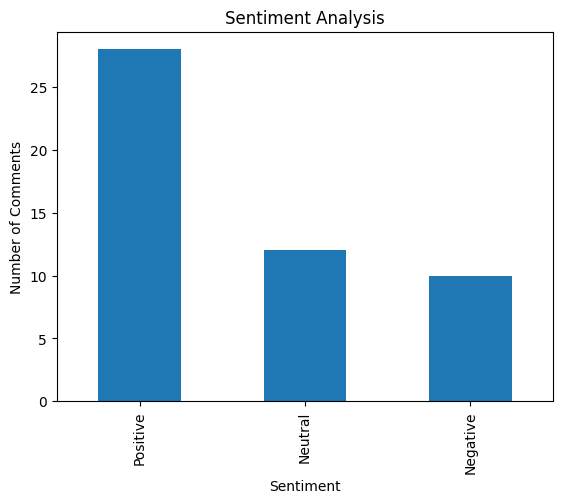

In [19]:
df["Sentiment"].value_counts().plot(
    kind='bar'
)

plt.title("Sentiment Analysis")

plt.xlabel("Sentiment")

plt.ylabel("Number of Comments")

plt.show()

In [20]:
text = " ".join(df["Cleaned"])

print(text)

product amazing worst customer service ever love new design disappointed quality excellent experience worth money fast delivery great packaging app keeps crashing highly recommended terrible support team product exceeded expectations packaging damaged arrived easy use userfriendly price high quality customer support solved issue quickly definitely buy battery life excellent stopped working one week great value money color exactly shown poor build quality received wrong product installation simple quick website easy navigate shipping delayed several days fantastic features smooth performance product looks premium satisfied purchase sound quality outstanding camera quality disappointing amazing customer experience refund process slow design modern attractive performance better expected product arrived time love quality finish best purchase made instructions confusing excellent packaging fast shipping customer support polite app slow unresponsive highly durable reliable would never recomm

In [21]:
from collections import Counter

words = text.split()

counter = Counter(words)

print(counter.most_common(10))

[('product', 8), ('quality', 7), ('customer', 5), ('support', 4), ('excellent', 3), ('packaging', 3), ('purchase', 3), ('amazing', 2), ('service', 2), ('love', 2)]


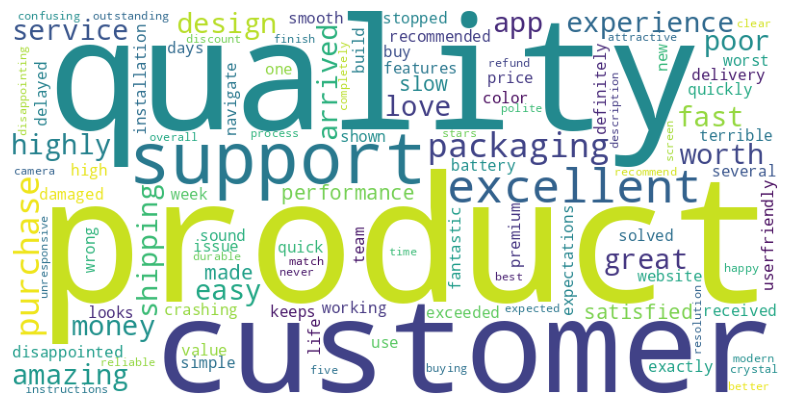

In [22]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.show()